In [99]:
import pandas
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np

data_full = pandas.read_csv("phase0-titanic/titanic_full.csv")

grouped = data_full.groupby('pclass')['survived']

for pclass, group in grouped:
    total_passengers = group.count()
    total_survived = group.sum()                 
    percentage_survived = round(group.mean() * 100, 2)  
    
    print(f"Class {pclass}:")
    print(f"  Total in class : {total_passengers}")
    print(f"  Total survived : {total_survived}")
    print(f"  Percentage survived : {percentage_survived}%\n")

Class 1st:
  Total in class : 324
  Total survived : 201
  Percentage survived : 62.04%

Class 2nd:
  Total in class : 284
  Total survived : 118
  Percentage survived : 41.55%

Class 3rd:
  Total in class : 709
  Total survived : 181
  Percentage survived : 25.53%

Class deck crew:
  Total in class : 66
  Total survived : 43
  Percentage survived : 65.15%

Class engineering crew:
  Total in class : 324
  Total survived : 71
  Percentage survived : 21.91%

Class restaurant staff:
  Total in class : 69
  Total survived : 3
  Percentage survived : 4.35%

Class victualling crew:
  Total in class : 431
  Total survived : 94
  Percentage survived : 21.81%



In [100]:
columns = ['pclass', 'sex', 'age', 'embarked']
x = data_full[columns]
y = data_full['survived']

x['age'] = x['age'].fillna(x['age'].median())
x['embarked'] = x['embarked'].fillna(x['embarked'].mode()[0])

x['is_crew'] = ~data_full['pclass'].isin(['1st','2nd','3rd'])
x['is_crew'] = x['is_crew'].astype(int)
x['embarked'] = x['embarked'].fillna(x['embarked'].mode()[0])
x["sex"] = x["sex"].map({"male":0, "female":1}).astype(int)

x = pandas.get_dummies(x, columns=['pclass'],drop_first=False)
x = pandas.get_dummies(x, columns=['embarked'], drop_first=False)
x = x.drop(columns=['is_crew'])

As the given data set does not include a test set, a 5 fold cross validation was added.

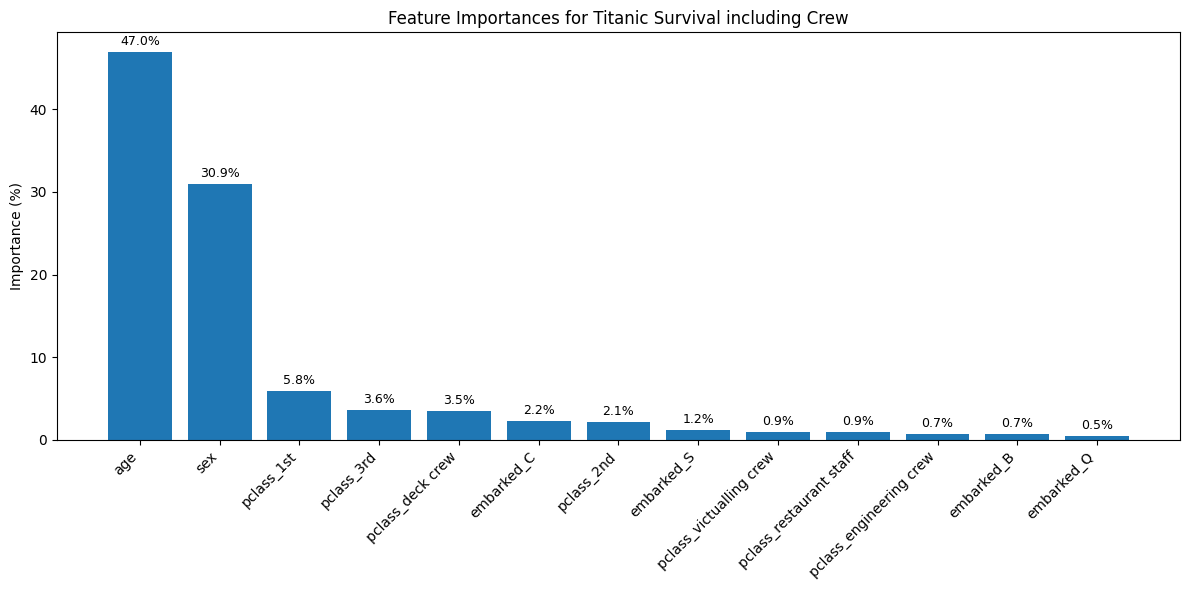

In [101]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x, y)

importances = pandas.Series(rf.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)

importances_percent = importances * 100

plt.figure(figsize=(12,6))
bars = plt.bar(importances_percent.index, importances_percent.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Importance (%)")
plt.title("Feature Importances for Titanic Survival including Crew")

for bar, pct in zip(bars, importances_percent.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Conclusion

When including the crew in its survival rate, it appears that whether the induvidual is a crew or passenger, the most important features are the sex and age. This is regardless if the dataset include just passengers or crew and passengers. It does appear that the importance of age increased when including the crew. 